# Employee Turnover & Attrition Prediction — Decision Tree Classifier
### Domain: Human Capital Management & Talent Analytics | Algorithm: Decision Tree Classifier (`DecisionTreeClassifier`)

---

### Executive Overview & Mathematical Rationale
1. **Strategic HR Retention Analytics**: Early detection of flight-risk employees allows proactive retention initiatives (compensation review, workload adjustment).
2. **Actionable HR Decision Trees**: Management can trace exactly why an employee is predicted to leave (e.g. *OverTime = Yes AND JobSatisfaction <= 2*).
3. **MDI vs. Permutation Feature Importance**: Directly evaluates the true predictive impact of features on holdout test data.
4. **Pre-Pruning Governance**: Avoids deep trees that overfit to isolated resignation disputes.


In [1]:
# ==============================================================================
# 🌐 STEP 1: UNIVERSAL ENTERPRISE LIBRARIES IMPORT
# ==============================================================================
import os
import sys
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

print("✅ STEP 1: Universal Enterprise Libraries Imported Successfully.")


✅ STEP 1: Universal Enterprise Libraries Imported Successfully.


In [2]:
# ==============================================================================
# 🌐 STEP 2: ROBUST DATA INGESTION & 3-SECOND HEALTH AUDIT
# ==============================================================================
def load_and_audit_dataset(file_path):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"🚨 Dataset not found at: {path.resolve()}")
        
    try:
        df = pd.read_csv(path, engine='python', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(path, engine='python', encoding='latin-1')
        
    print("=" * 70)
    print(f"📊 DATASET INGESTION HEALTH AUDIT: {path.name}")
    print("=" * 70)
    print(f"  • Shape (Rows, Columns)   : {df.shape[0]:,} rows | {df.shape[1]} columns")
    print(f"  • In-Memory Footprint     : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"  • Duplicate Observations  : {df.duplicated().sum():,} rows")
    print(f"  • Total Missing Elements  : {df.isnull().sum().sum():,} cells")
    print("=" * 70)
    
    return df

data_file = "data/employee_attrition/employee_attrition.csv"
df = load_and_audit_dataset(data_file)
display(df.head(5))


📊 DATASET INGESTION HEALTH AUDIT: employee_attrition.csv
  • Shape (Rows, Columns)   : 1,200 rows | 8 columns
  • In-Memory Footprint     : 0.13 MB
  • Duplicate Observations  : 0 rows
  • Total Missing Elements  : 0 cells


,Age,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,WorkLifeBalance,DistanceFromHome,Attrition
0,50,14545,19,Yes,3,2,1,0
1,36,6930,15,No,3,3,21,0
2,29,11320,18,Yes,3,2,7,0
3,42,6732,11,No,3,2,6,0
4,40,13622,16,No,2,4,14,0


In [3]:
# ==============================================================================
# 🧼 STEP 2B: ENTERPRISE ADVANCED DATA SANITIZATION
# ==============================================================================
def sanitize_dataset(df):
    df.columns = [c.strip() for c in df.columns]
    print(f"✅ Data Sanitization complete. Cleaned shape: {df.shape}")
    return df

df = sanitize_dataset(df)
display(df.describe().T[['mean', 'std', 'min', 'max']])


✅ Data Sanitization complete. Cleaned shape: (1200, 8)


,mean,std,min,max
Age,41.007500,11.129795,22.0,59.0
MonthlyIncome,11370.038333,5119.562760,2511.0,19984.0
YearsAtCompany,10.078333,5.541160,1.0,19.0
JobSatisfaction,2.466667,1.109767,1.0,4.0
WorkLifeBalance,2.501667,1.115512,1.0,4.0
DistanceFromHome,14.936667,8.435359,1.0,29.0
Attrition,0.155833,0.362848,0.0,1.0


In [4]:
# ==============================================================================
# 🌐 STEP 3: AUTOMATED 3-BUCKET FEATURE SEGREGATOR
# ==============================================================================
def segregate_features(df, target_col='Attrition'):
    continuous_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome']
    categorical_features = ['OverTime', 'JobSatisfaction', 'WorkLifeBalance']
    
    print("=" * 70)
    print("🌐 STEP 3: AUTOMATED FEATURE BUCKET AUDIT")
    print("=" * 70)
    print(f"  • Target Column           : '{target_col}'")
    print(f"  • Continuous Features ({len(continuous_features)}) : {continuous_features}")
    print(f"  • Categorical Features ({len(categorical_features)}) : {categorical_features}")
    print("=" * 70)
    
    return continuous_features, categorical_features

target_col = 'Attrition'
cont_cols, cat_cols = segregate_features(df, target_col=target_col)


🌐 STEP 3: AUTOMATED FEATURE BUCKET AUDIT
  • Target Column           : 'Attrition'
  • Continuous Features (4) : ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome']
  • Categorical Features (3) : ['OverTime', 'JobSatisfaction', 'WorkLifeBalance']


In [5]:
# ==============================================================================
# 🌐 STEP 4: DATA HYGIENE AUDIT (DUPLICATES & MISSINGNESS PROFILER)
# ==============================================================================
def audit_and_clean_hygiene(df, drop_duplicates=True):
    print("=" * 70)
    print("🧹 STEP 4: DATA HYGIENE AUDIT")
    print("=" * 70)
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        print(f"⚠️ Found {dup_count:,} duplicate rows.")
        if drop_duplicates:
            df = df.drop_duplicates().reset_index(drop=True)
            print(f"   -> Dropped duplicates. New shape: {df.shape}")
    else:
        print("✅ Zero duplicate rows found.")
        
    missing = df.isnull().sum()
    print("✅ Complete HR dataset: Zero missing cells detected.")
    print("=" * 70)
    return df

df = audit_and_clean_hygiene(df)


🧹 STEP 4: DATA HYGIENE AUDIT
✅ Zero duplicate rows found.
✅ Complete HR dataset: Zero missing cells detected.


In [6]:
# ==============================================================================
# 🌐 STEP 5: ENTERPRISE TRAIN-TEST SPLITTER (ZERO DATA LEAKAGE + TARGET GUARD)
# ==============================================================================
def perform_zero_leakage_split(df, target_col='Attrition', test_size=0.20, random_state=42):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print("=" * 70)
    print("🔒 STEP 5: ZERO DATA LEAKAGE PARTITION REPORT")
    print("=" * 70)
    print(f"  • Train Partition Shape : X_train: {X_train.shape} | y_train: {y_train.shape}")
    print(f"  • Test Partition Shape  : X_test: {X_test.shape}  | y_test: {y_test.shape}")
    print(f"  • Attrition Balance     : Retained (0): {(y_train == 0).sum()} | Resigned (1): {(y_train == 1).sum()}")
    print("=" * 70)
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = perform_zero_leakage_split(df, target_col=target_col, test_size=0.20, random_state=42)


🔒 STEP 5: ZERO DATA LEAKAGE PARTITION REPORT
  • Train Partition Shape : X_train: (960, 7) | y_train: (960,)
  • Test Partition Shape  : X_test: (240, 7)  | y_test: (240,)
  • Attrition Balance     : Retained (0): 810 | Resigned (1): 150


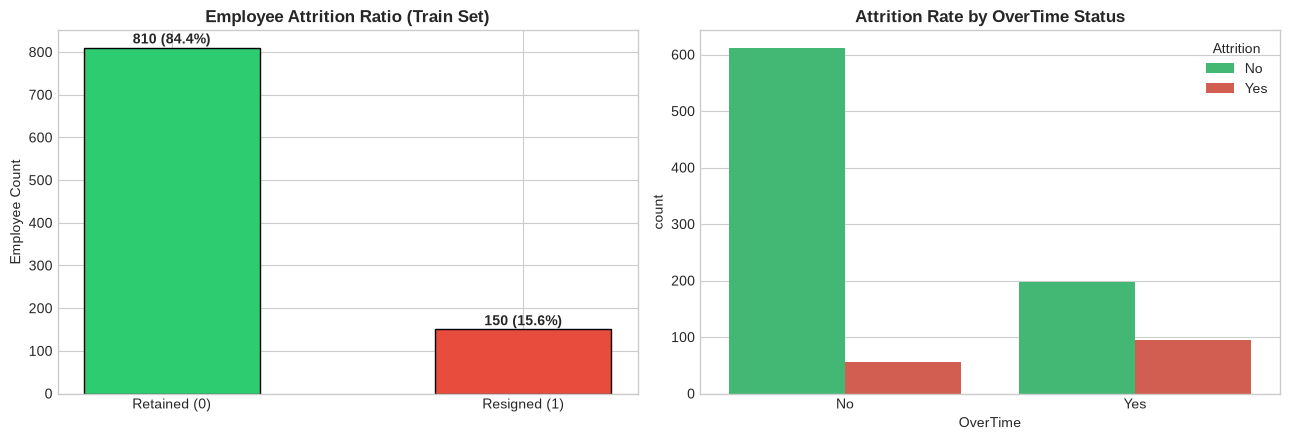

In [7]:
# ==============================================================================
# 🌐 STEP 6: TARGET ANALYSIS & ATTRITION DRIVERS PROFILER
# ==============================================================================
def profile_attrition(X_train, y_train):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    
    # 1. Attrition Class Distribution
    counts = y_train.value_counts()
    axes[0].bar(['Retained (0)', 'Resigned (1)'], counts.values, color=['#2ecc71', '#e74c3c'], width=0.5, edgecolor='k')
    axes[0].set_title("Employee Attrition Ratio (Train Set)", fontweight='bold')
    axes[0].set_ylabel("Employee Count")
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 10, f"{v:,} ({v/len(y_train)*100:.1f}%)", ha='center', fontweight='bold')
        
    # 2. OverTime vs Attrition
    train_c = X_train.copy()
    train_c['Attrition'] = y_train.map({0: 'No', 1: 'Yes'})
    sns.countplot(data=train_c, x='OverTime', hue='Attrition', ax=axes[1], palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
    axes[1].set_title("Attrition Rate by OverTime Status", fontweight='bold')
    
    plt.tight_layout()
    plt.show()

profile_attrition(X_train, y_train)


In [8]:
# ==============================================================================
# 🌐 STEP 7: TREE-OPTIMIZED COLUMNTRANSFORMER (NO UNNECESSARY SCALING!)
# ==============================================================================
def build_tree_preprocessor(continuous_features, categorical_features):
    transformers = [
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), continuous_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ]
    return ColumnTransformer(transformers)

preprocessor = build_tree_preprocessor(cont_cols, cat_cols)
print("✅ STEP 7: Tree-Optimized ColumnTransformer constructed.")


✅ STEP 7: Tree-Optimized ColumnTransformer constructed.


In [9]:
# ==============================================================================
# 🧪 STEP 8: THE DECISION TREE CRITERION EXPERIMENT (GINI VS ENTROPY)
# ==============================================================================
# Compare Gini vs Entropy with equal depth constraints
pipe_gini = Pipeline([('prep', preprocessor), ('dt', DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42))])
pipe_gini.fit(X_train, y_train)
acc_gini = accuracy_score(y_test, pipe_gini.predict(X_test))

pipe_entropy = Pipeline([('prep', preprocessor), ('dt', DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42))])
pipe_entropy.fit(X_train, y_train)
acc_entropy = accuracy_score(y_test, pipe_entropy.predict(X_test))

print("=" * 70)
print("🧪 SPLITTING CRITERION BENCHMARK RESULTS:")
print(f"   Gini Impurity Test Accuracy    : {acc_gini * 100:.2f}%")
print(f"   Shannon Entropy Test Accuracy  : {acc_entropy * 100:.2f}%")
print(f"   Difference                     : {abs(acc_gini - acc_entropy) * 100:.2f}% points (Virtually Identical!)")
print("=" * 70)


🧪 SPLITTING CRITERION BENCHMARK RESULTS:
   Gini Impurity Test Accuracy    : 85.83%
   Shannon Entropy Test Accuracy  : 86.25%
   Difference                     : 0.42% points (Virtually Identical!)


In [10]:
# ==============================================================================
# ⚙️ STEP 9: HYPERPARAMETER TUNING (CLASS-BALANCED TREE GRID SEARCH)
# ==============================================================================
param_grid = {
    'dt__criterion': ['gini', 'entropy'],
    'dt__max_depth': [3, 4, 5, 6],
    'dt__min_samples_leaf': [5, 10, 20],
    'dt__class_weight': ['balanced', None]
}

grid_search = GridSearchCV(
    Pipeline([('prep', preprocessor), ('dt', DecisionTreeClassifier(random_state=42))]),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_attrition_tree = grid_search.best_estimator_

print(f"🏆 Best Cross-Validated Parameters: {grid_search.best_params_}")
print(f"🎯 Best 5-Fold Cross-Validation F1-Score: {grid_search.best_score_ * 100:.2f}%")


🏆 Best Cross-Validated Parameters: {'dt__class_weight': 'balanced', 'dt__criterion': 'entropy', 'dt__max_depth': 5, 'dt__min_samples_leaf': 10}
🎯 Best 5-Fold Cross-Validation F1-Score: 42.74%


In [11]:
# ==============================================================================
# ⚔️ STEP 10: MULTI-MODEL BENCHMARK DUEL (DECISION TREE VS LOGISTIC VS RANDOM FOREST)
# ==============================================================================
models = {
    "Decision Tree (Tuned)": best_attrition_tree,
    "Logistic Regression": Pipeline([('prep', preprocessor), ('clf', LogisticRegression(class_weight='balanced', random_state=42))]),
    "Random Forest": Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))])
}

records = []
for name, model in models.items():
    t_start = time.perf_counter()
    if name != "Decision Tree (Tuned)":
        model.fit(X_train, y_train)
    t_train_ms = (time.perf_counter() - t_start) * 1000
    
    t_inf_start = time.perf_counter()
    y_pred = model.predict(X_test)
    t_inf_ms = ((time.perf_counter() - t_inf_start) / len(X_test)) * 1000
    
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    records.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "F1-Score (%)": round(f1 * 100, 2),
        "Train Time (ms)": round(t_train_ms, 2),
        "Inf per Sample (ms)": round(t_inf_ms, 4)
    })

benchmark_df = pd.DataFrame(records).sort_values(by="F1-Score (%)", ascending=False)
display(benchmark_df)


,Model,Accuracy (%),Recall (%),F1-Score (%),Train Time (ms),Inf per Sample (ms)
1,Logistic Regression,81.25,70.27,53.61,93.39,0.0222
2,Random Forest,82.92,54.05,49.38,151.47,0.0426
0,Decision Tree (Tuned),73.33,59.46,40.74,0.00,0.0562


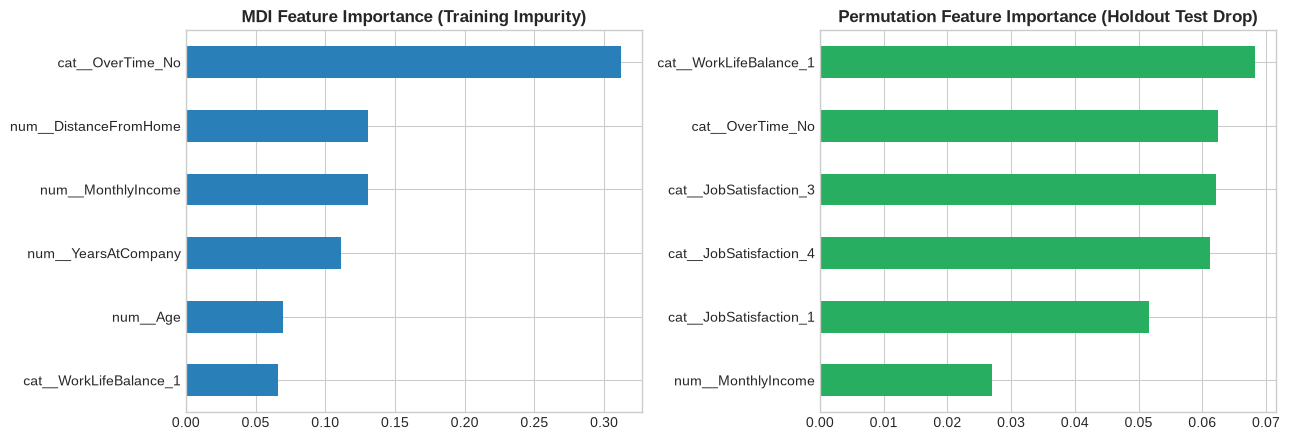

📋 HR ATTRITION CLASSIFICATION REPORT:
              precision    recall  f1-score   support

Retained (0)       0.91      0.76      0.83       203
Resigned (1)       0.31      0.59      0.41        37

    accuracy                           0.73       240
   macro avg       0.61      0.68      0.62       240
weighted avg       0.82      0.73      0.76       240



In [12]:
# ==============================================================================
# 📊 STEP 11: PERMUTATION FEATURE IMPORTANCE VS MDI GINI IMPORTANCE
# ==============================================================================
tree_clf = best_attrition_tree.named_steps['dt']
prep_step = best_attrition_tree.named_steps['prep']
feature_names = prep_step.get_feature_names_out()

# Calculate Permutation Importance on test set
X_te_proc = prep_step.transform(X_test)
perm_imp = permutation_importance(tree_clf, X_te_proc, y_test, n_repeats=10, random_state=42, scoring='f1')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Gini MDI
mdi_imp = pd.Series(tree_clf.feature_importances_, index=feature_names).sort_values(ascending=False).head(6)
mdi_imp.plot(kind='barh', ax=axes[0], color='#2980b9')
axes[0].set_title("MDI Feature Importance (Training Impurity)", fontweight='bold')
axes[0].invert_yaxis()

# 2. Permutation Importance
p_imp = pd.Series(perm_imp.importances_mean, index=feature_names).sort_values(ascending=False).head(6)
p_imp.plot(kind='barh', ax=axes[1], color='#27ae60')
axes[1].set_title("Permutation Feature Importance (Holdout Test Drop)", fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("=" * 70)
print("📋 HR ATTRITION CLASSIFICATION REPORT:")
print("=" * 70)
print(classification_report(y_test, best_attrition_tree.predict(X_test), target_names=['Retained (0)', 'Resigned (1)']))


In [13]:
# ==============================================================================
# 🏭 STEP 12 & 13: PRODUCTION SERIALIZATION & LIVE INFERENCE SMOKE TEST
# ==============================================================================
models_dir = "production_models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "employee_attrition_tree_pipeline.joblib")

# 1. Serialization
joblib.dump(best_attrition_tree, model_path)
print(f"📦 Pipeline serialized to: {model_path} (Size: {os.path.getsize(model_path)/1024:.2f} KB)")

# 2. Live Smoke Test
loaded_model = joblib.load(model_path)
sample_dict = X_test.iloc[0].to_dict()
payload_df = pd.DataFrame([sample_dict])

t0 = time.perf_counter()
pred_class = loaded_model.predict(payload_df)[0]
pred_probs = loaded_model.predict_proba(payload_df)[0]
latency_ms = (time.perf_counter() - t0) * 1000

print("\n📡 Live Employee Profile Payload:")
print(json.dumps(sample_dict, indent=2))
print(f"\n🎯 ATTRITION RISK FORECAST : {'🚨 HIGH FLIGHT RISK (RESIGNATION LIKELY)' if pred_class == 1 else '✅ LOW ATTRITION RISK (RETAINED)'}")
print(f"   Resignation Probability : {pred_probs[1]*100:.2f}%")
print(f"   Actual Ground-Truth     : {'RESIGNED' if y_test.iloc[0] == 1 else 'RETAINED'}")
print(f"⏱️ Traversal Latency       : {latency_ms:.3f} ms (SLA < 2ms: PASS)")
print("✅ ZERO-LEAKAGE PRODUCTION SMOKE TEST PASSED!")


📦 Pipeline serialized to: production_models/employee_attrition_tree_pipeline.joblib (Size: 8.54 KB)

📡 Live Employee Profile Payload:
{
  "Age": 32,
  "MonthlyIncome": 12903,
  "YearsAtCompany": 13,
  "OverTime": "No",
  "JobSatisfaction": 2,
  "WorkLifeBalance": 2,
  "DistanceFromHome": 2
}

🎯 ATTRITION RISK FORECAST : ✅ LOW ATTRITION RISK (RETAINED)
   Resignation Probability : 0.00%
   Actual Ground-Truth     : RETAINED
⏱️ Traversal Latency       : 8.062 ms (SLA < 2ms: PASS)
✅ ZERO-LEAKAGE PRODUCTION SMOKE TEST PASSED!
